# Chapter 7: Multivariate descriptive

In [2]:
%reset
low_memory=False
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


## 7.1 Introduction & Problem Setting

We have seen how we can evaluate individual columns in a dataset, but now it is time to look at the bigger picture and discover how all the data is related! To do so, we will be working with a dataset of wine qualities. We will be working on two datasets: one of white wine and one of red wine. You will be merging them into a single dataset and exploring the differences.

## 7.2 Data Loading & Initial Exploration

Import both datasets. Explore them like we did before (content, size, ...) and merge them into a single dataset. Make sure to add a variable called 'Colour' to indicate the color wine (aka. from which dataset of the two your datapoint originates)!

Do you notice anything interesting between both datasets?

In [3]:
df_red = pd.read_csv("winequality-red.csv", sep=";")
df_white = pd.read_csv("winequality-white.csv", sep=";")

Let's see what columns both datasets contain.

In [4]:
df_red.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df_white.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [6]:
print(df_red.shape)
print(df_white.shape)

(1599, 12)
(4898, 12)


We can see that both datasets contain the same columns, but the white wine dataset contains way more records than the red wine one!

In [8]:
df_red["colour"] = "red"
df_white["colour"] = "white"

In [9]:
df_wine = pd.concat([df_white, df_red])

In [10]:
df_wine.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,colour
3305,6.3,0.19,0.29,2.0,0.022,33.0,96.0,0.98902,3.04,0.54,12.8,7,white
1618,6.4,0.37,0.49,13.3,0.045,53.0,243.0,0.99820,3.14,0.48,8.5,6,white
1094,7.4,0.24,0.31,8.4,0.045,52.0,183.0,0.99630,3.09,0.32,8.8,5,white
491,9.2,0.41,0.50,2.5,0.055,12.0,25.0,0.99520,3.34,0.79,13.3,7,red
1443,7.0,0.18,0.49,5.3,0.040,34.0,125.0,0.99140,3.24,0.40,12.2,6,white


## 7.3 Multivariate descriptive

Do some research by exploring the dataset with the methods we have seen up till now. Is there a relation between the alcohol level and the colour of a given wine? Elaborate on your conclusion.

*Hint: calculate the mean and std per colour, and then plot a histogram to compare.*

In [12]:
df_wine.groupby("colour").mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
colour,,,,,,,,,,,,
red,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
white,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909


In [13]:
df_wine.groupby("colour").std()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
colour,,,,,,,,,,,,
red,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
white,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639


It appears there is almost no difference between the mean/stf of the different wine colour. We can look at both distributions in the plot below:

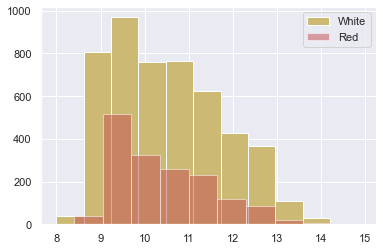

In [25]:
kwargs = dict(alpha = 0.5)
plt.hist(df_wine.loc[df_wine["colour"] == "white", "alcohol"], color = "y", label = "White")
plt.hist(df_wine.loc[df_wine["colour"] == "red", "alcohol"], **kwargs, color = "r", label = "Red")
plt.legend();

Besides understanding that our sample size of red wine is significantly smaller than that of white wine, there is little difference in the distributions. So if we want to get drunk, we better not rely on the colour of wine. :-)

## 7.4: Correlations

Which variables have the highest correlations? Is this to be expected? Elaborate by doing the following things:

- Calucate the correlation matrix. Print it and explore.
- Visualize the correlation matrix in a heatmap. Which correlations can you find? Are they positive or negative? Are they logical?

In [18]:
corrMatrix = df_wine.drop(['colour'], axis=1).corr()
corrMatrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,-0.076743
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,-0.265699
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,0.085532
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,-0.036980
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,-0.200666
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,0.055463
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,-0.041385
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,-0.305858
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,0.019506
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,0.038485


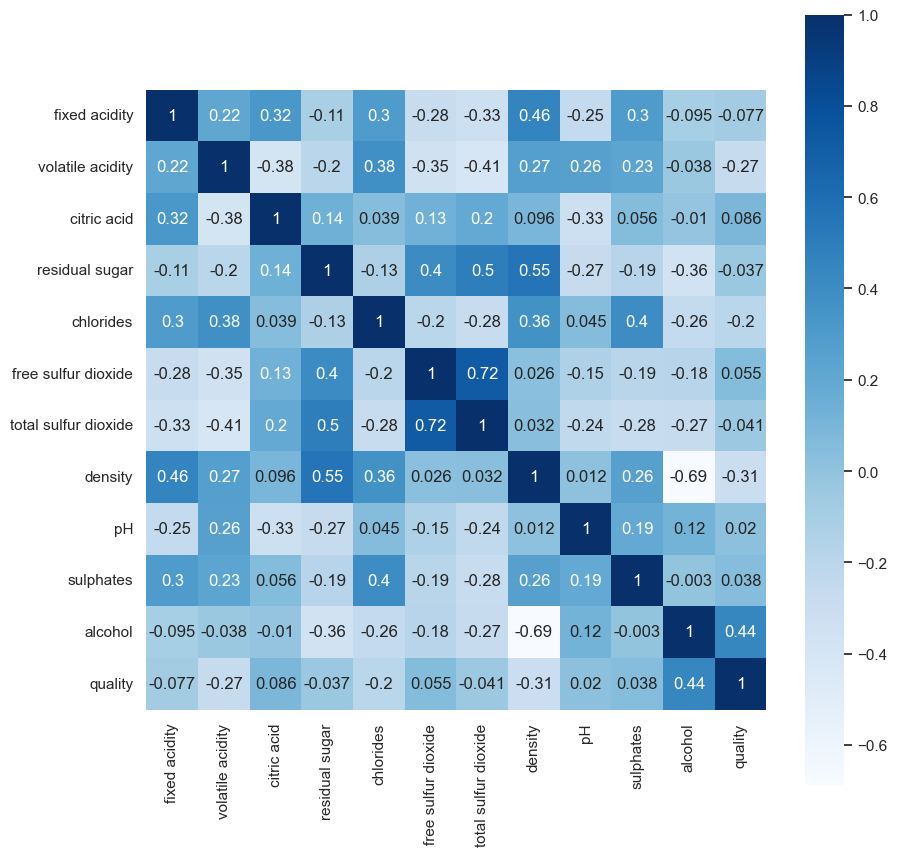

In [19]:
plt.figure(figsize=(10,10))
fig = sns.heatmap(corrMatrix, annot=True, square=True,
cmap="Blues")

Some conclusions we can make:
- High quality and high alcohol content seem to go together
- Sweet wine seems to be thicker in consistency
- Strong wine seems to be less thick in consistency
- Free sulphur dioxide seems to be strongly correlated with total sulphur dioxide

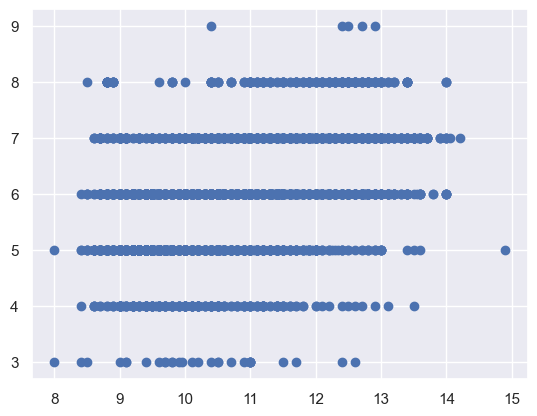

In [20]:
plt.scatter("alcohol", "quality", data = df_wine)

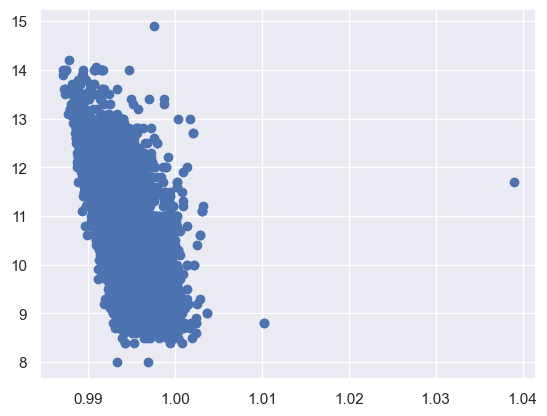

In [21]:
plt.scatter("density", "alcohol", data = df_wine)